1.

In [41]:
import numpy as np

In [42]:
arr = np.zeros(10)
arr[4] = 1              # индексация с нуля → «пятый» = индекс 4

arr_2d = arr.reshape(2, 5)
print(arr)
print(arr_2d)

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]


In [43]:
arr = np.arange(10, 50)          # 10..49
reversed_arr = arr[::-1]         # развёрнутый
evens = arr[arr % 2 == 0]        # чётные из исходного

print(arr)
print(reversed_arr)
print(evens)

[10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
[49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26
 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10]
[10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48]


In [44]:
arr = np.arange(9).reshape(3, 3)
print(arr)

[[0 1 2]
 [3 4 5]
 [6 7 8]]


In [45]:
arr = np.random.rand(4, 3, 2)
print(arr)
print("min:", arr.min())
print("max:", arr.max())

[[[0.28206785 0.12247716]
  [0.7084788  0.15480504]
  [0.81229981 0.11323241]]

 [[0.10996583 0.47805521]
  [0.99080244 0.1012972 ]
  [0.26664842 0.59116813]]

 [[0.19235942 0.03608921]
  [0.78741563 0.77613844]
  [0.58075573 0.58167463]]

 [[0.49145757 0.28729724]
  [0.04370807 0.93384151]
  [0.75751674 0.4933679 ]]]
min: 0.036089211327782755
max: 0.9908024431077729


In [46]:
a = np.random.rand(6, 4)
b = np.random.rand(4, 3)

c = a @ b          # или np.dot(a, b), или a.dot(b)
print(c.shape)     # (6, 3)

(6, 3)


In [47]:
arr = np.random.rand(7, 7)

mean = arr.mean()
std = arr.std()
print("mean:", mean, "std:", std)

# Нормализация: (x - mean) / std → mean≈0, std≈1
normalized = (arr - mean) / std
print("после нормализации: mean =", normalized.mean(), "std =", normalized.std())

mean: 0.43698219007067496 std: 0.2770998741487376
после нормализации: mean = 4.531522549490435e-17 std = 1.0


2.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
tips = sns.load_dataset("tips")

In [50]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [51]:
tips.shape          # (244, 7) — кортеж (строки, колонки)
# или
print(f"Строк: {tips.shape[0]}, колонок: {tips.shape[1]}")

Строк: 244, колонок: 7


In [52]:
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [53]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [54]:
tips["total_bill"].max()

np.float64(50.81)

In [55]:
(tips["smoker"] == "Yes").sum()
# или
tips["smoker"].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [56]:
tips.groupby("day")["total_bill"].mean()

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64

In [57]:
median_bill = tips["total_bill"].median()
filtered = tips[tips["total_bill"] > median_bill]
filtered.groupby("sex")["tip"].mean()

sex
Male      3.756404
Female    3.663939
Name: tip, dtype: float64

In [58]:
tips["smoker_bin"] = (tips["smoker"] == "Yes").astype(int)
tips[["smoker", "smoker_bin"]].head()

,smoker,smoker_bin
0,No,0
1,No,0
2,No,0
3,No,0
4,No,0


3.

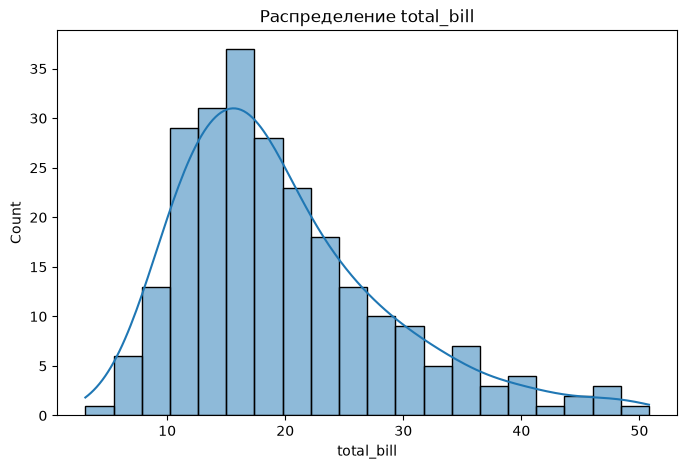

In [59]:
plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x="total_bill", bins=20, kde=True)
plt.title("Распределение total_bill")
plt.show()

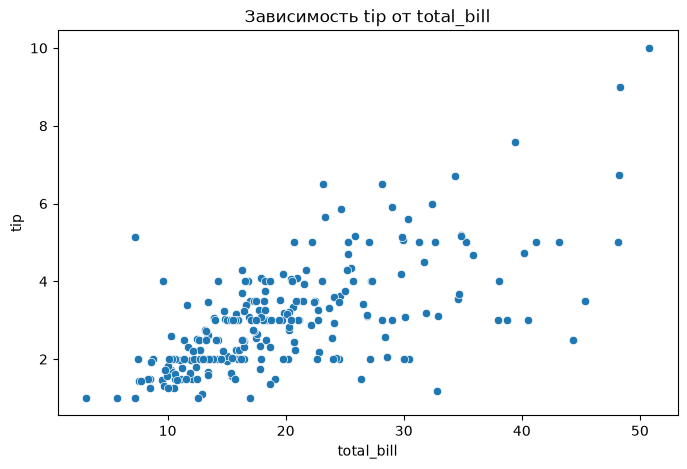

In [60]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.title("Зависимость tip от total_bill")
plt.show()

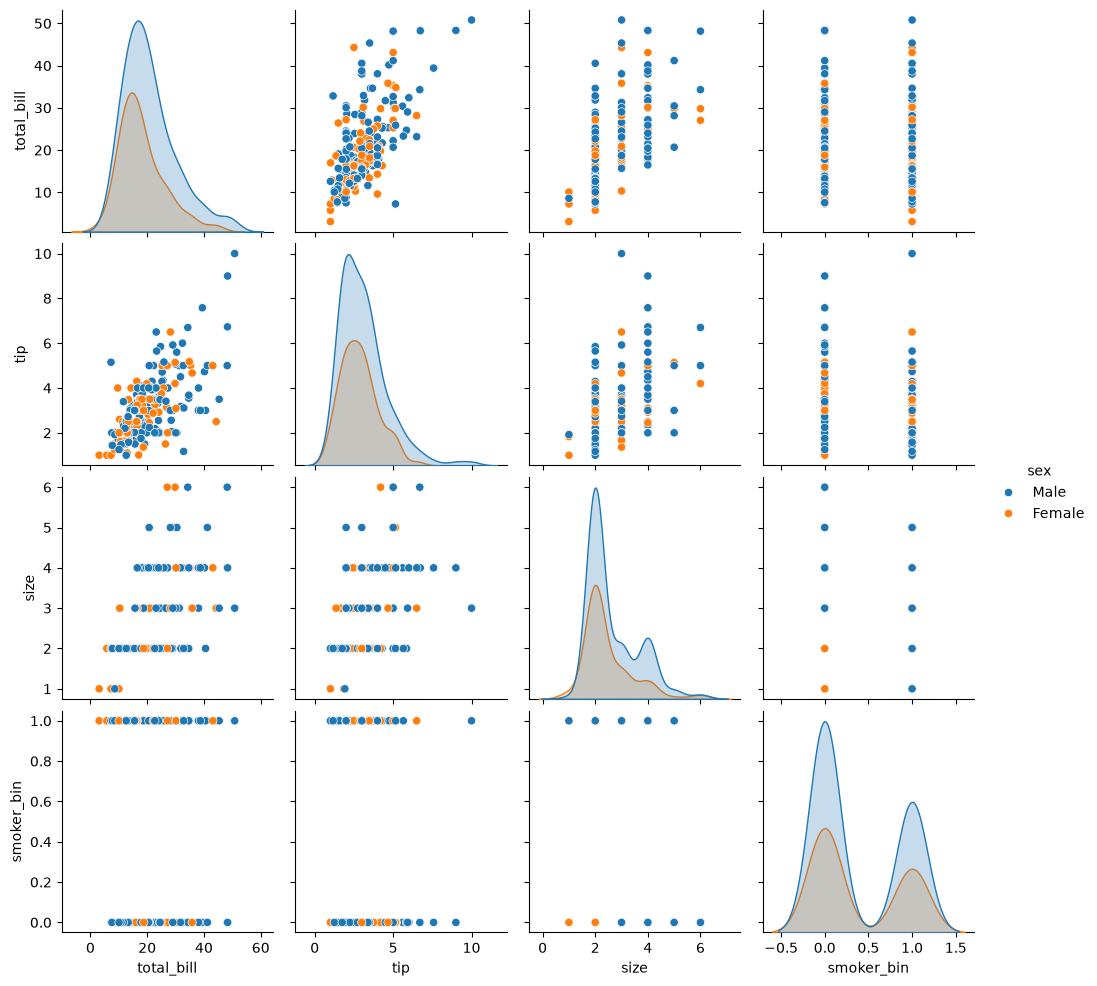

In [61]:
sns.pairplot(tips, hue="sex")
plt.show()

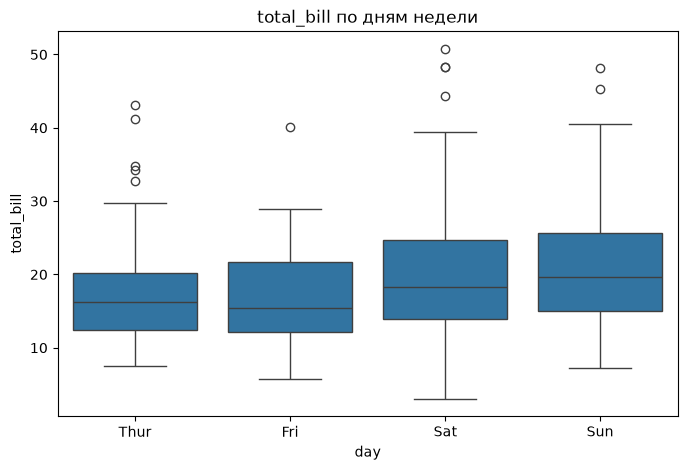

In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=tips, x="day", y="total_bill")
plt.title("total_bill по дням недели")
plt.show()

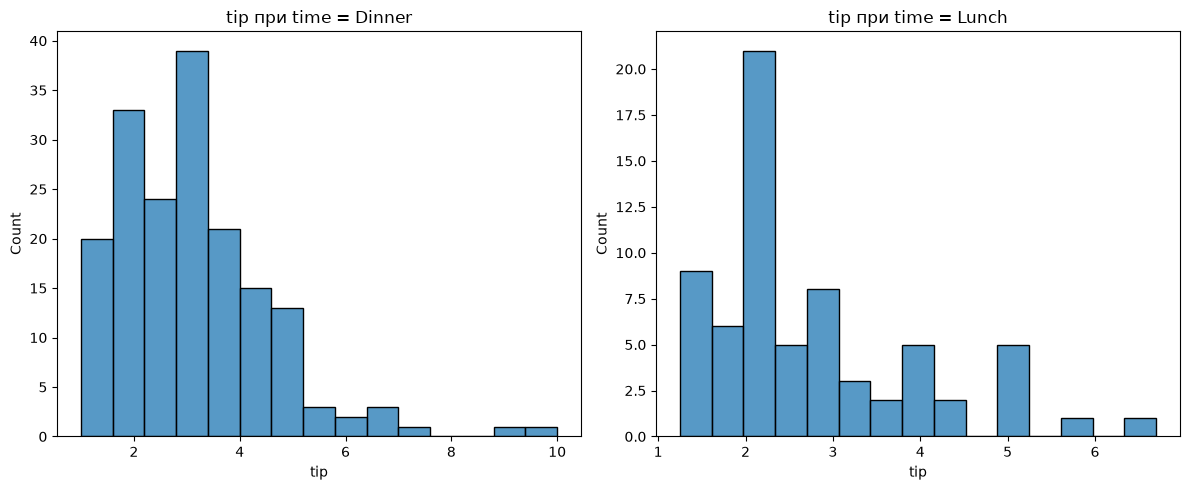

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, t in zip(axes, tips["time"].unique()):
    sns.histplot(data=tips[tips["time"] == t], x="tip", bins=15, ax=ax)
    ax.set_title(f"tip при time = {t}")

plt.tight_layout()
plt.show()

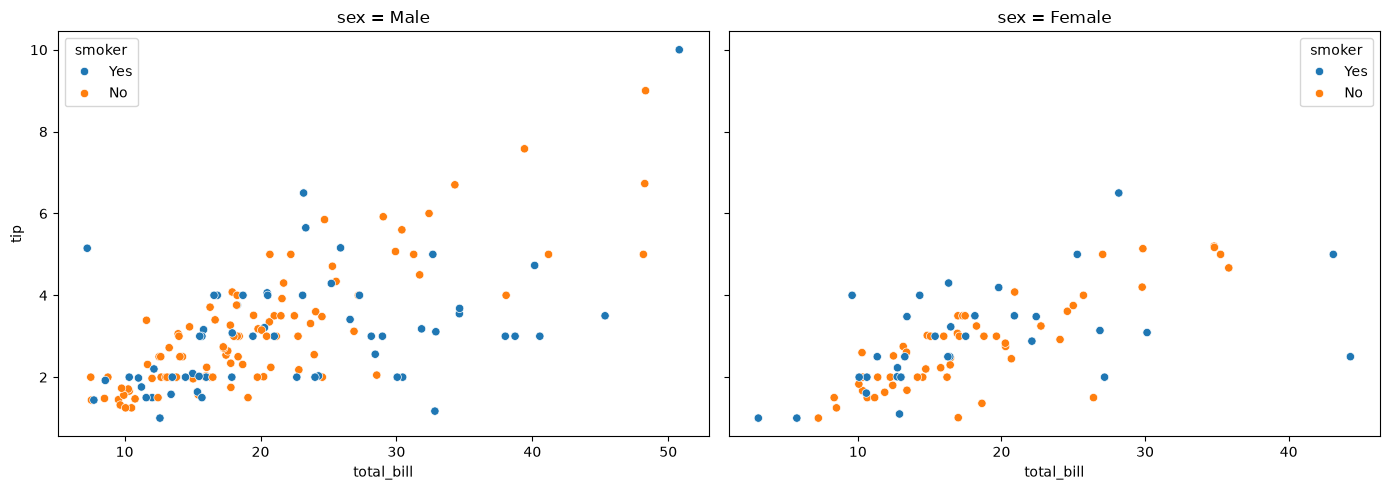

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, sex in zip(axes, ["Male", "Female"]):
    subset = tips[tips["sex"] == sex]
    sns.scatterplot(data=subset, x="total_bill", y="tip",
                    hue="smoker", ax=ax)
    ax.set_title(f"sex = {sex}")

plt.tight_layout()
plt.show()

1. Данные чистые. Пропусков в датасете Tips нет — все 244 строки заполнены по всем 7 колонкам. Предобработка не требуется, можно сразу переходить к анализу.

2. total_bill распределён с правым хвостом. Большинство чеков — в диапазоне 10–25 долларов, но есть выбросы до ~50. Средний чек ≈ 19.8, медиана ≈ 17.8 — среднее выше медианы именно из-за выбросов, это классическая картина скошенного вправо распределения.

3. tip тоже скошен вправо. Большинство чаевых — 2–4 доллара, среднее ≈ 3.0, медиана = 2.9, максимум = 10. По гистограмме видно, что подавляющая часть значений сосредоточена в узком диапазоне, а редкие крупные чаевые вытягивают хвост вправо.

4. total_bill и tip сильно и положительно связаны. На scatterplot облако точек чётко тянется по диагонали: чем больше счёт, тем больше чаевые. Корреляция Пирсона между ними ≈ 0.68 — заметная и ожидаемая связь. При этом разброс увеличивается с ростом чека: маленькие счета дают стабильно маленькие чаевые, а большие — очень разные.

5. Чаевые зависят от дня недели. По группировке видно, что средний чек выше всего в субботу и воскресенье (≈ 20–21), ниже — в пятницу и особенно в четверг (≈ 17). Это согласуется с житейской логикой: в выходные приходят большими компаниями и тратят больше.

6. Разница по полу небольшая. Средние чаевые у мужчин и женщин близки (≈ 3.09 у мужчин против ≈ 2.83 у женщин на всём датасете), но если отфильтровать чеки выше медианы — разрыв ещё меньше. Основной вклад в разницу даёт не пол клиента, а размер счёта.

7. Курящие и некурящие оставляют схожие чаевые. Признак smoker слабо влияет на tip: на диаграмме «Male/Female» точки обоих цветов перемешаны, без явной кластеризации. Как отдельный предиктор чаевых smoker малополезен.

8. Время приёма пищи тоже влияет. Ужины (Dinner) дают гораздо более широкий разброс по tip, чем обеды (Lunch): за ужином больше столов, крупнее счета, отсюда и больше крупных чаевых. У Lunch распределение узкое и смещено к меньшим значениям.